In [1]:
# ============================================================
# MEMBER 4
# VISUALIZATION & INTERPRETATION
# STEPS 57–70
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

from IPython.display import display

%matplotlib inline

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    200
)


# ============================================================
# FILE PATHS
# ============================================================

INPUT_FILE = (
    r"C:\Users\admin\OneDrive\Desktop\DS- Activity 1\backblaze_analytical_dataset.csv"
)

OUTPUT_FOLDER = (
    "output/visualizations"
)

os.makedirs(
    OUTPUT_FOLDER,
    exist_ok=True
)


# ============================================================
# HELPER FUNCTION
# JUPYTER + TERMINAL + CSV
# ============================================================

def show_and_save(
    data,
    filename,
    title
):

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    # JUPYTER
    display(data)

    # TERMINAL
    try:

        sys.__stdout__.write(
            "\n" +
            "=" * 70 +
            "\n" +
            title +
            "\n" +
            "=" * 70 +
            "\n" +
            data.to_string(
                index=False
            ) +
            "\n"
        )

        sys.__stdout__.flush()

    except Exception:
        pass

    # CSV
    filepath = os.path.join(
        OUTPUT_FOLDER,
        filename
    )

    data.to_csv(
        filepath,
        index=False
    )

    print(
        "\nSaved CSV:"
    )

    print(
        filepath
    )

    return data

In [2]:
# ============================================================
# STEP 57 — LOAD CLEANED DATASET
# ============================================================

print("\n" + "=" * 70)
print("STEP 57 — LOAD CLEANED DATASET")
print("=" * 70)

df = pd.read_csv(
    INPUT_FILE
)

print(
    "Rows:",
    df.shape[0]
)

print(
    "Columns:",
    df.shape[1]
)

try:

    sys.__stdout__.write(
        f"\nSTEP 57 — Rows: {df.shape[0]}, "
        f"Columns: {df.shape[1]}\n"
    )

    sys.__stdout__.flush()

except Exception:
    pass


STEP 57 — LOAD CLEANED DATASET
Rows: 30943146
Columns: 19


In [3]:
# ============================================================
# STEP 58 — IDENTIFY COLUMNS
# ============================================================

print("\n" + "=" * 70)
print("STEP 58 — COLUMN IDENTIFICATION")
print("=" * 70)

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print(
    "\nNumerical Columns:"
)

print(
    numeric_columns
)

print(
    "\nCategorical Columns:"
)

print(
    categorical_columns
)


# ============================================================
# TARGET COLUMN
# ============================================================

possible_targets = [

    "failure",

    "failed",

    "disk_failure",

    "disk_failed",

    "failure_status",

    "target",

    "label"
]

target_column = None

for column in possible_targets:

    if column in df.columns:

        target_column = column

        break


print(
    "\nTarget Column:",
    target_column
)


STEP 58 — COLUMN IDENTIFICATION

Numerical Columns:
['capacity_bytes', 'failure', 'smart_5_normalized', 'smart_5_raw', 'smart_9_normalized', 'smart_9_raw', 'smart_90_normalized', 'smart_90_raw', 'smart_187_normalized', 'smart_187_raw', 'smart_188_normalized', 'smart_188_raw', 'smart_197_normalized', 'smart_197_raw', 'smart_198_normalized', 'smart_198_raw']

Categorical Columns:
['date', 'serial_number', 'model']

Target Column: failure


In [4]:
# ============================================================
# STEP 59 — FEATURE SELECTION
# ============================================================

print("\n" + "=" * 70)
print("STEP 59 — FEATURE SELECTION")
print("=" * 70)

feature_columns = (
    numeric_columns.copy()
)

if target_column in feature_columns:

    feature_columns.remove(
        target_column
    )

selected_features = (
    feature_columns[:6]
)

selected_features_df = pd.DataFrame({

    "Selected_Feature":
        selected_features
})

show_and_save(
    selected_features_df,
    "step_59_selected_features.csv",
    "STEP 59 — SELECTED FEATURES"
)


STEP 59 — FEATURE SELECTION

STEP 59 — SELECTED FEATURES


,Selected_Feature
0,capacity_bytes
1,smart_5_normalized
2,smart_5_raw
3,smart_9_normalized
4,smart_9_raw
5,smart_90_normalized



Saved CSV:
output/visualizations\step_59_selected_features.csv


,Selected_Feature
0,capacity_bytes
1,smart_5_normalized
2,smart_5_raw
3,smart_9_normalized
4,smart_9_raw
5,smart_90_normalized



STEP 60 — BAR CHART

STEP 60 — BAR CHART DATA


,Category,Count
0,0,30942092
1,1,1054



Saved CSV:
output/visualizations\step_60_bar_chart_data.csv


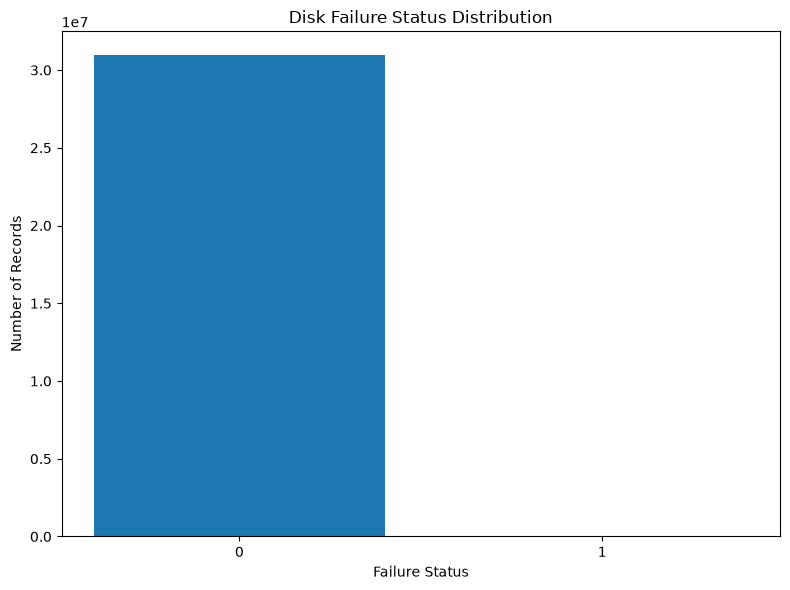


Interpretation:
The bar chart shows the distribution of disk failure status. The category '0' has the highest number of observations with 30942092 records.

Graph saved: output/visualizations\step_60_bar_chart.png


In [5]:
# ============================================================
# STEP 60 — BAR CHART
# ============================================================

print("\n" + "=" * 70)
print("STEP 60 — BAR CHART")
print("=" * 70)

if target_column:

    target_counts = (
        df[target_column]
        .value_counts()
        .sort_index()
    )

    target_result = pd.DataFrame({

        "Category":
            target_counts
            .index
            .astype(str),

        "Count":
            target_counts
            .values
    })

    show_and_save(
        target_result,
        "step_60_bar_chart_data.csv",
        "STEP 60 — BAR CHART DATA"
    )

    plt.figure(
        figsize=(8, 6)
    )

    plt.bar(
        target_result["Category"],
        target_result["Count"]
    )

    plt.title(
        "Disk Failure Status Distribution"
    )

    plt.xlabel(
        "Failure Status"
    )

    plt.ylabel(
        "Number of Records"
    )

    plt.xticks(
        rotation=0
    )

    plt.tight_layout()

    graph_path = os.path.join(
        OUTPUT_FOLDER,
        "step_60_bar_chart.png"
    )

    plt.savefig(
        graph_path,
        dpi=300,
        bbox_inches="tight"
    )

    # JUPYTER
    plt.show()

    plt.close()

    largest_category = (
        target_counts.idxmax()
    )

    largest_count = (
        target_counts.max()
    )

    interpretation = (

        f"The bar chart shows the distribution "
        f"of disk failure status. The category "
        f"'{largest_category}' has the highest "
        f"number of observations with "
        f"{largest_count} records."
    )

    print(
        "\nInterpretation:"
    )

    print(
        interpretation
    )

    interpretation_df = pd.DataFrame({

        "Step": [60],

        "Graph": [
            "Bar Chart"
        ],

        "Interpretation": [
            interpretation
        ]
    })

    interpretation_df.to_csv(
        os.path.join(
            OUTPUT_FOLDER,
            "step_60_bar_chart_interpretation.csv"
        ),
        index=False
    )

    print(
        "\nGraph saved:",
        graph_path
    )


STEP 61 — LINE CHART


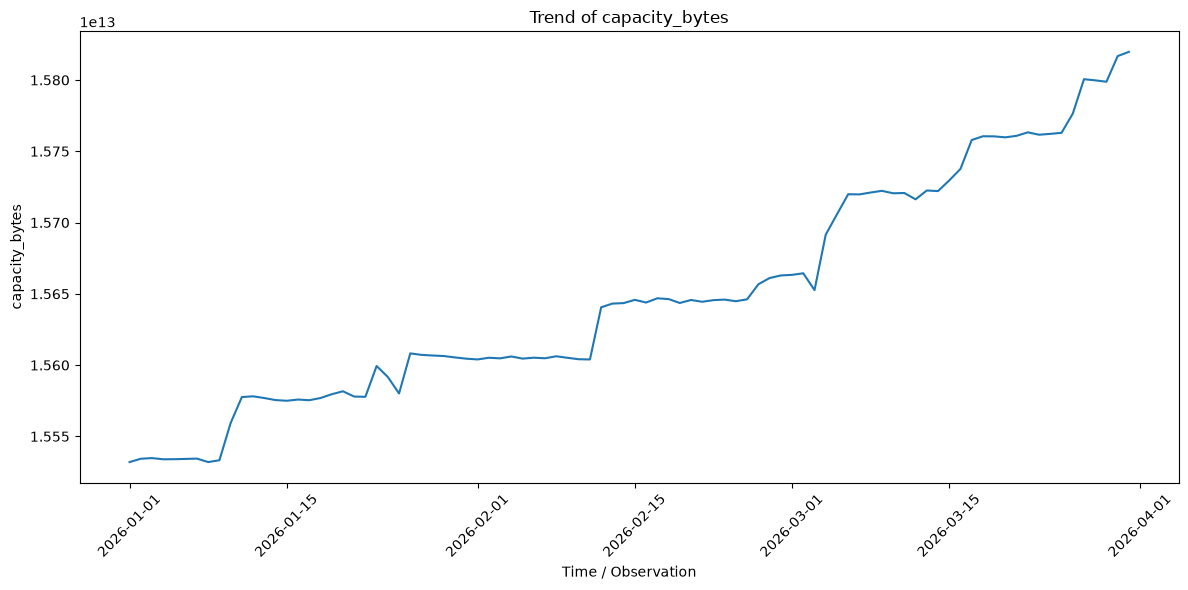


Interpretation:
The line chart shows the variation of capacity_bytes. The overall pattern is increasing.

STEP 61 — LINE CHART RESULT


,Feature,Trend,Interpretation
0,capacity_bytes,increasing,The line chart shows the variation of capacity...



Saved CSV:
output/visualizations\step_61_line_chart_result.csv

Graph saved: output/visualizations\step_61_line_chart.png


In [6]:
# ============================================================
# STEP 61 — LINE CHART
# ============================================================

print("\n" + "=" * 70)
print("STEP 61 — LINE CHART")
print("=" * 70)

feature = selected_features[0]

datetime_columns = []

for column in df.columns:

    column_lower = column.lower()

    if any(
        keyword in column_lower
        for keyword in [
            "date",
            "time",
            "timestamp"
        ]
    ):

        datetime_columns.append(
            column
        )


if len(datetime_columns) > 0:

    date_column = (
        datetime_columns[0]
    )

    temp_df = df.copy()

    temp_df[date_column] = (
        pd.to_datetime(
            temp_df[date_column],
            errors="coerce"
        )
    )

    temp_df = temp_df.dropna(
        subset=[
            date_column
        ]
    )

    if len(temp_df) > 0:

        trend_data = (

            temp_df

            .set_index(
                date_column
            )[feature]

            .resample(
                "D"
            )

            .mean()

            .dropna()
        )

        x_values = (
            trend_data.index
        )

        y_values = (
            trend_data.values
        )

    else:

        trend_data = (
            df[feature]
            .head(100)
            .reset_index(
                drop=True
            )
        )

        x_values = (
            trend_data.index
        )

        y_values = (
            trend_data.values
        )

else:

    trend_data = (
        df[feature]
        .head(100)
        .reset_index(
            drop=True
        )
    )

    x_values = (
        trend_data.index
    )

    y_values = (
        trend_data.values
    )


plt.figure(
    figsize=(12, 6)
)

plt.plot(
    x_values,
    y_values
)

plt.title(
    f"Trend of {feature}"
)

plt.xlabel(
    "Time / Observation"
)

plt.ylabel(
    feature
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

graph_path = os.path.join(
    OUTPUT_FOLDER,
    "step_61_line_chart.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

if len(y_values) >= 2:

    if y_values[-1] > y_values[0]:

        trend_direction = (
            "increasing"
        )

    elif y_values[-1] < y_values[0]:

        trend_direction = (
            "decreasing"
        )

    else:

        trend_direction = (
            "relatively stable"
        )

else:

    trend_direction = (
        "not enough observations"
    )


interpretation = (

    f"The line chart shows the variation "
    f"of {feature}. The overall pattern "
    f"is {trend_direction}."
)

print(
    "\nInterpretation:"
)

print(
    interpretation
)

line_result = pd.DataFrame({

    "Feature": [
        feature
    ],

    "Trend": [
        trend_direction
    ],

    "Interpretation": [
        interpretation
    ]
})

show_and_save(
    line_result,
    "step_61_line_chart_result.csv",
    "STEP 61 — LINE CHART RESULT"
)

print(
    "\nGraph saved:",
    graph_path
)


STEP 62 — HISTOGRAM


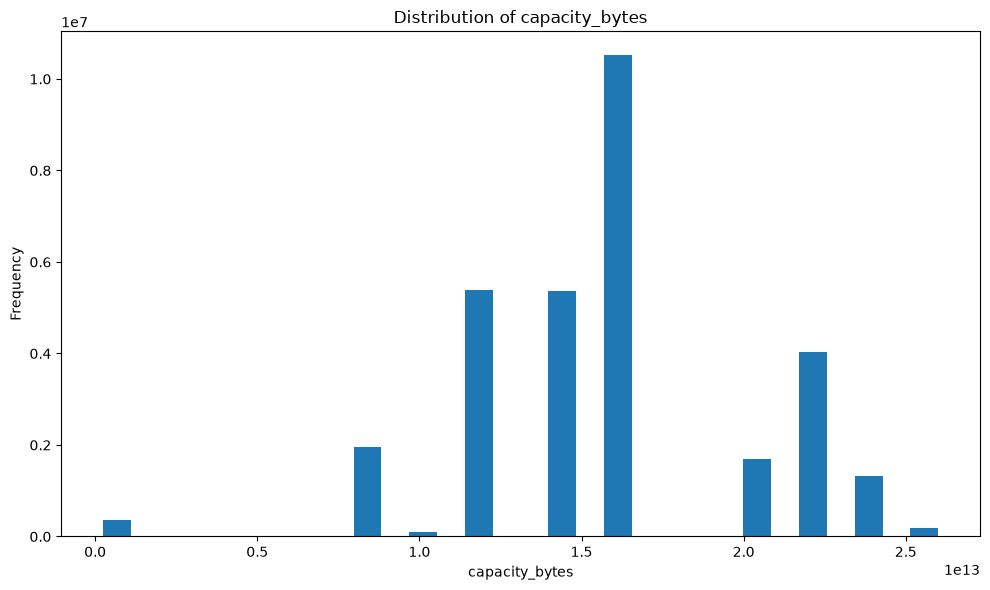


STEP 62 — HISTOGRAM RESULT


,Feature,Skewness,Distribution,Interpretation
0,capacity_bytes,-0.130304,Approximately symmetric,The histogram shows the distribution of capaci...



Saved CSV:
output/visualizations\step_62_histogram_result.csv

Graph saved: output/visualizations\step_62_histogram.png


In [7]:
# ============================================================
# STEP 62 — HISTOGRAM
# ============================================================

print("\n" + "=" * 70)
print("STEP 62 — HISTOGRAM")
print("=" * 70)

feature = (
    selected_features[0]
)

skew_value = (
    df[feature].skew()
)

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    df[feature].dropna(),
    bins=30
)

plt.title(
    f"Distribution of {feature}"
)

plt.xlabel(
    feature
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

graph_path = os.path.join(
    OUTPUT_FOLDER,
    "step_62_histogram.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


if skew_value > 1:

    distribution_type = (
        "Highly positively skewed"
    )

elif skew_value > 0.5:

    distribution_type = (
        "Moderately positively skewed"
    )

elif skew_value < -1:

    distribution_type = (
        "Highly negatively skewed"
    )

elif skew_value < -0.5:

    distribution_type = (
        "Moderately negatively skewed"
    )

else:

    distribution_type = (
        "Approximately symmetric"
    )


interpretation = (

    f"The histogram shows the distribution "
    f"of {feature}. The distribution is "
    f"{distribution_type}, with a skewness "
    f"value of {skew_value:.2f}."
)

hist_result = pd.DataFrame({

    "Feature": [
        feature
    ],

    "Skewness": [
        skew_value
    ],

    "Distribution": [
        distribution_type
    ],

    "Interpretation": [
        interpretation
    ]
})

show_and_save(
    hist_result,
    "step_62_histogram_result.csv",
    "STEP 62 — HISTOGRAM RESULT"
)

print(
    "\nGraph saved:",
    graph_path
)


STEP 63 — SCATTER PLOT


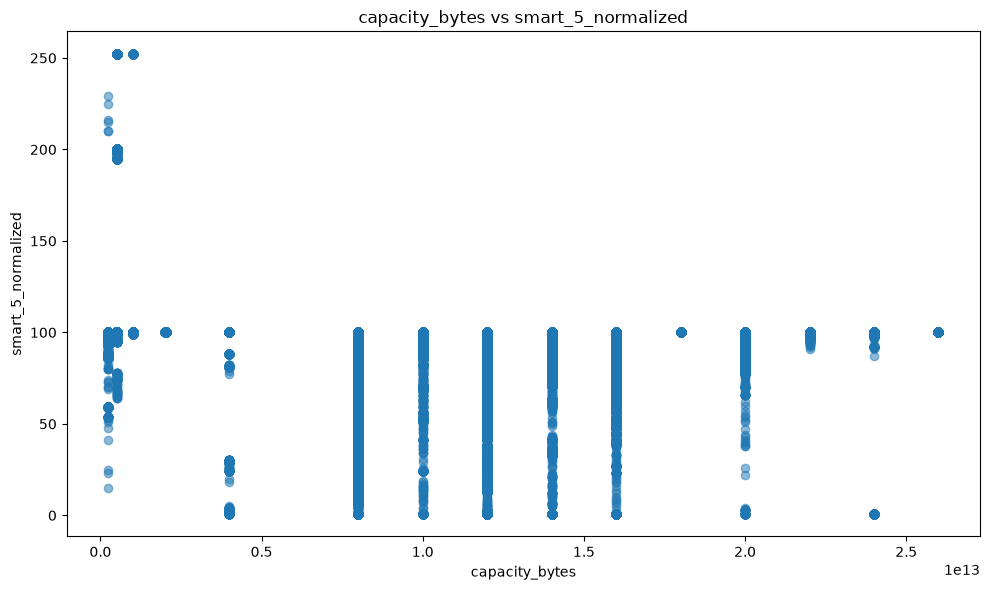


STEP 63 — SCATTER PLOT RESULT


,Feature_X,Feature_Y,Correlation,Relationship,Interpretation
0,capacity_bytes,smart_5_normalized,-0.04467,Very weak / negligible,The scatter plot compares capacity_bytes and s...



Saved CSV:
output/visualizations\step_63_scatter_result.csv

Graph saved: output/visualizations\step_63_scatter_plot.png


In [8]:
# ============================================================
# STEP 63 — SCATTER PLOT
# ============================================================

print("\n" + "=" * 70)
print("STEP 63 — SCATTER PLOT")
print("=" * 70)

if len(selected_features) >= 2:

    feature_x = (
        selected_features[0]
    )

    feature_y = (
        selected_features[1]
    )

    correlation = (
        df[
            [
                feature_x,
                feature_y
            ]
        ]
        .corr()
        .iloc[0, 1]
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.scatter(
        df[feature_x],
        df[feature_y],
        alpha=0.5
    )

    plt.title(
        f"{feature_x} vs {feature_y}"
    )

    plt.xlabel(
        feature_x
    )

    plt.ylabel(
        feature_y
    )

    plt.tight_layout()

    graph_path = os.path.join(
        OUTPUT_FOLDER,
        "step_63_scatter_plot.png"
    )

    plt.savefig(
        graph_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


    if abs(correlation) >= 0.7:

        relationship = "Strong"

    elif abs(correlation) >= 0.4:

        relationship = "Moderate"

    elif abs(correlation) >= 0.2:

        relationship = "Weak"

    else:

        relationship = (
            "Very weak / negligible"
        )


    interpretation = (

        f"The scatter plot compares "
        f"{feature_x} and {feature_y}. "
        f"The correlation is "
        f"{correlation:.2f}, indicating a "
        f"{relationship.lower()} relationship."
    )


    scatter_result = pd.DataFrame({

        "Feature_X": [
            feature_x
        ],

        "Feature_Y": [
            feature_y
        ],

        "Correlation": [
            correlation
        ],

        "Relationship": [
            relationship
        ],

        "Interpretation": [
            interpretation
        ]
    })


    show_and_save(
        scatter_result,
        "step_63_scatter_result.csv",
        "STEP 63 — SCATTER PLOT RESULT"
    )

    print(
        "\nGraph saved:",
        graph_path
    )


STEP 64 — BOX PLOT


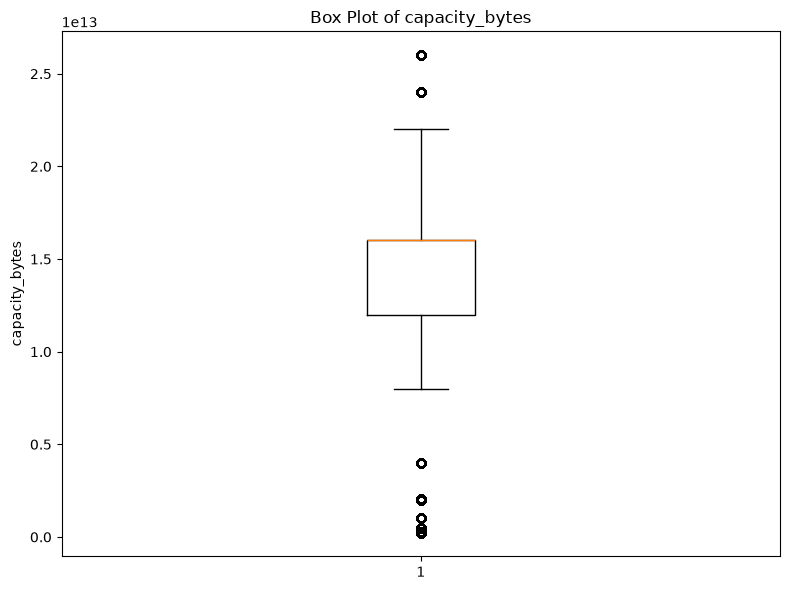


STEP 64 — BOX PLOT RESULT


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Potential_Outliers
0,capacity_bytes,1.200014e+13,1.600090e+13,4.000762e+12,5.998996e+12,2.200204e+13,1892988



Saved CSV:
output/visualizations\step_64_box_plot_result.csv

Interpretation:
The box plot shows the spread, median and quartiles of capacity_bytes. There are approximately 1,892,988 potential outliers using the IQR method.

Graph saved: output/visualizations\step_64_box_plot.png


In [9]:
# ============================================================
# STEP 64 — BOX PLOT
# ============================================================

print("\n" + "=" * 70)
print("STEP 64 — BOX PLOT")
print("=" * 70)

feature = (
    selected_features[0]
)

Q1 = (
    df[feature]
    .quantile(0.25)
)

Q3 = (
    df[feature]
    .quantile(0.75)
)

IQR = (
    Q3 - Q1
)

lower_bound = (
    Q1 - 1.5 * IQR
)

upper_bound = (
    Q3 + 1.5 * IQR
)

outliers = df[
    (df[feature] < lower_bound)
    |
    (df[feature] > upper_bound)
]


plt.figure(
    figsize=(8, 6)
)

plt.boxplot(
    df[feature].dropna()
)

plt.title(
    f"Box Plot of {feature}"
)

plt.ylabel(
    feature
)

plt.tight_layout()

graph_path = os.path.join(
    OUTPUT_FOLDER,
    "step_64_box_plot.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


box_result = pd.DataFrame({

    "Feature": [
        feature
    ],

    "Q1": [
        Q1
    ],

    "Q3": [
        Q3
    ],

    "IQR": [
        IQR
    ],

    "Lower_Bound": [
        lower_bound
    ],

    "Upper_Bound": [
        upper_bound
    ],

    "Potential_Outliers": [
        len(outliers)
    ]
})


show_and_save(
    box_result,
    "step_64_box_plot_result.csv",
    "STEP 64 — BOX PLOT RESULT"
)

print(
    "\nInterpretation:"
)

print(

    f"The box plot shows the spread, median "
    f"and quartiles of {feature}. "
    f"There are approximately "
    f"{len(outliers):,} potential outliers "
    f"using the IQR method."
)

print(
    "\nGraph saved:",
    graph_path
)


STEP 65 — PIE CHART

STEP 65 — PIE CHART DATA


,Category,Count,Percentage
0,0,30942092,99.996594
1,1,1054,0.003406



Saved CSV:
output/visualizations\step_65_pie_chart_data.csv


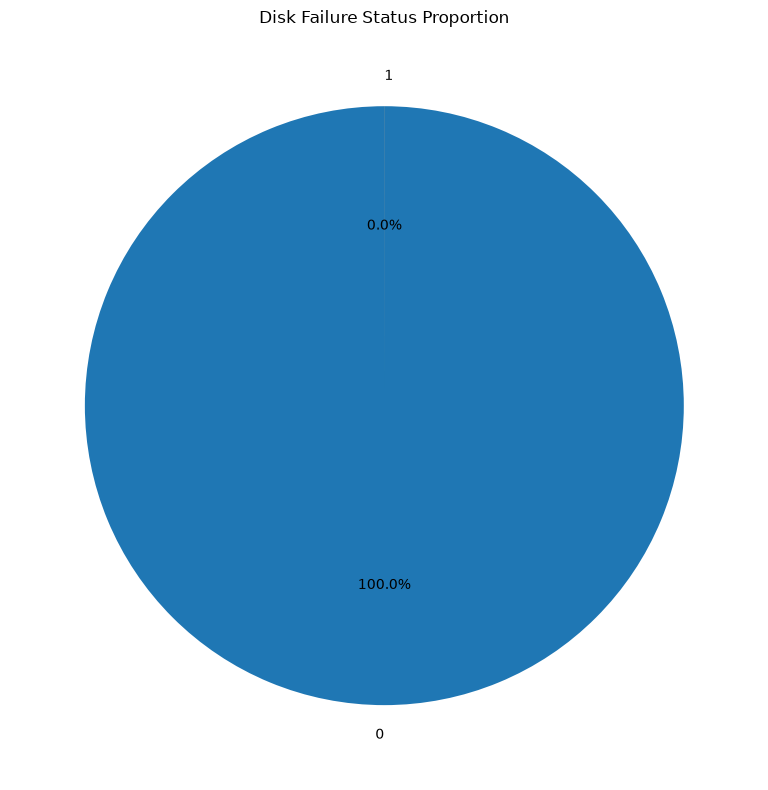


Interpretation:
The pie chart shows the proportion of failure categories. '0' represents the largest proportion at 100.00%.

Graph saved: output/visualizations\step_65_pie_chart.png


In [10]:
# ============================================================
# STEP 65 — PIE CHART
# ============================================================

print("\n" + "=" * 70)
print("STEP 65 — PIE CHART")
print("=" * 70)

if target_column:

    pie_data = (
        df[target_column]
        .value_counts()
    )

    pie_result = pd.DataFrame({

        "Category":
            pie_data.index.astype(str),

        "Count":
            pie_data.values,

        "Percentage":
            (
                pie_data.values
                /
                pie_data.values.sum()
                *
                100
            )
    })


    show_and_save(
        pie_result,
        "step_65_pie_chart_data.csv",
        "STEP 65 — PIE CHART DATA"
    )


    if len(pie_data) <= 6:

        plt.figure(
            figsize=(8, 8)
        )

        plt.pie(

            pie_data.values,

            labels=
                pie_data
                .index
                .astype(str),

            autopct="%1.1f%%",

            startangle=90
        )

        plt.title(
            "Disk Failure Status Proportion"
        )

        plt.tight_layout()

        graph_path = os.path.join(
            OUTPUT_FOLDER,
            "step_65_pie_chart.png"
        )

        plt.savefig(
            graph_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        plt.close()


        largest_category = (
            pie_data.idxmax()
        )

        largest_percentage = (

            pie_data.max()
            /
            pie_data.sum()
            *
            100
        )


        interpretation = (

            f"The pie chart shows the proportion "
            f"of failure categories. "
            f"'{largest_category}' represents "
            f"the largest proportion at "
            f"{largest_percentage:.2f}%."
        )


        print(
            "\nInterpretation:"
        )

        print(
            interpretation
        )


        pie_interpretation = pd.DataFrame({

            "Step": [
                65
            ],

            "Graph": [
                "Pie Chart"
            ],

            "Interpretation": [
                interpretation
            ]
        })


        pie_interpretation.to_csv(

            os.path.join(
                OUTPUT_FOLDER,
                "step_65_pie_chart_interpretation.csv"
            ),

            index=False
        )


        print(
            "\nGraph saved:",
            graph_path
        )

    else:

        print(
            "Pie chart skipped because there "
            "are more than 6 categories."
        )


else:

    print(
        "Target column was not detected."
    )


STEP 66 — CORRELATION HEATMAP


,capacity_bytes,failure,smart_5_normalized,smart_5_raw,smart_9_normalized,smart_9_raw,smart_90_normalized,smart_90_raw,smart_187_normalized,smart_187_raw,smart_188_normalized,smart_188_raw,smart_197_normalized,smart_197_raw,smart_198_normalized,smart_198_raw
capacity_bytes,1.000000,-0.001184,-0.044670,-0.055657,0.381113,-0.700703,NaN,-0.012504,0.071719,-0.002513,-0.001367,-0.008700,-0.072106,-0.001853,-0.039339,-0.001760
failure,-0.001184,1.000000,-0.011817,0.014024,-0.000546,0.001993,NaN,-0.000035,-0.044238,0.009072,-0.036524,0.006620,-0.007484,0.039558,-0.014159,0.037546
smart_5_normalized,-0.044670,-0.011817,1.000000,-0.291477,0.002428,0.034910,NaN,0.000001,0.397298,-0.070568,0.079715,-0.007481,0.857067,-0.044346,0.560889,-0.043418
smart_5_raw,-0.055657,0.014024,-0.291477,1.000000,-0.024892,0.043867,NaN,-0.000085,-0.521230,0.062572,-0.025987,0.005007,-0.003841,0.012066,-0.005163,0.012174
smart_9_normalized,0.381113,-0.000546,0.002428,-0.024892,1.000000,-0.581247,NaN,0.000715,0.062075,-0.001613,-0.001278,-0.017820,-0.008305,0.002043,0.017945,0.000525
smart_9_raw,-0.700703,0.001993,0.034910,0.043867,-0.581247,1.000000,NaN,-0.003918,-0.061517,0.001540,0.001295,0.017709,0.055798,0.001423,0.028147,0.001436
smart_90_normalized,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smart_90_raw,-0.012504,-0.000035,0.000001,-0.000085,0.000715,-0.003918,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,-0.000050,NaN,0.000090
smart_187_normalized,0.071719,-0.044238,0.397298,-0.521230,0.062075,-0.061517,NaN,NaN,1.000000,-0.165096,0.035482,-0.015066,0.094061,-0.054375,0.094061,-0.054375
smart_187_raw,-0.002513,0.009072,-0.070568,0.062572,-0.001613,0.001540,NaN,NaN,-0.165096,1.000000,-0.029712,0.004159,-0.015729,0.007662,-0.015729,0.007664


                      capacity_bytes   failure  smart_5_normalized  smart_5_raw  smart_9_normalized  smart_9_raw  smart_90_normalized  smart_90_raw  smart_187_normalized  smart_187_raw  smart_188_normalized  smart_188_raw  smart_197_normalized  smart_197_raw  smart_198_normalized  smart_198_raw
capacity_bytes              1.000000 -0.001184           -0.044670    -0.055657            0.381113    -0.700703                  NaN     -0.012504              0.071719      -0.002513             -0.001367      -0.008700             -0.072106      -0.001853             -0.039339      -0.001760
failure                    -0.001184  1.000000           -0.011817     0.014024           -0.000546     0.001993                  NaN     -0.000035             -0.044238       0.009072             -0.036524       0.006620             -0.007484       0.039558             -0.014159       0.037546
smart_5_normalized         -0.044670 -0.011817            1.000000    -0.291477            0.002428     0.034910

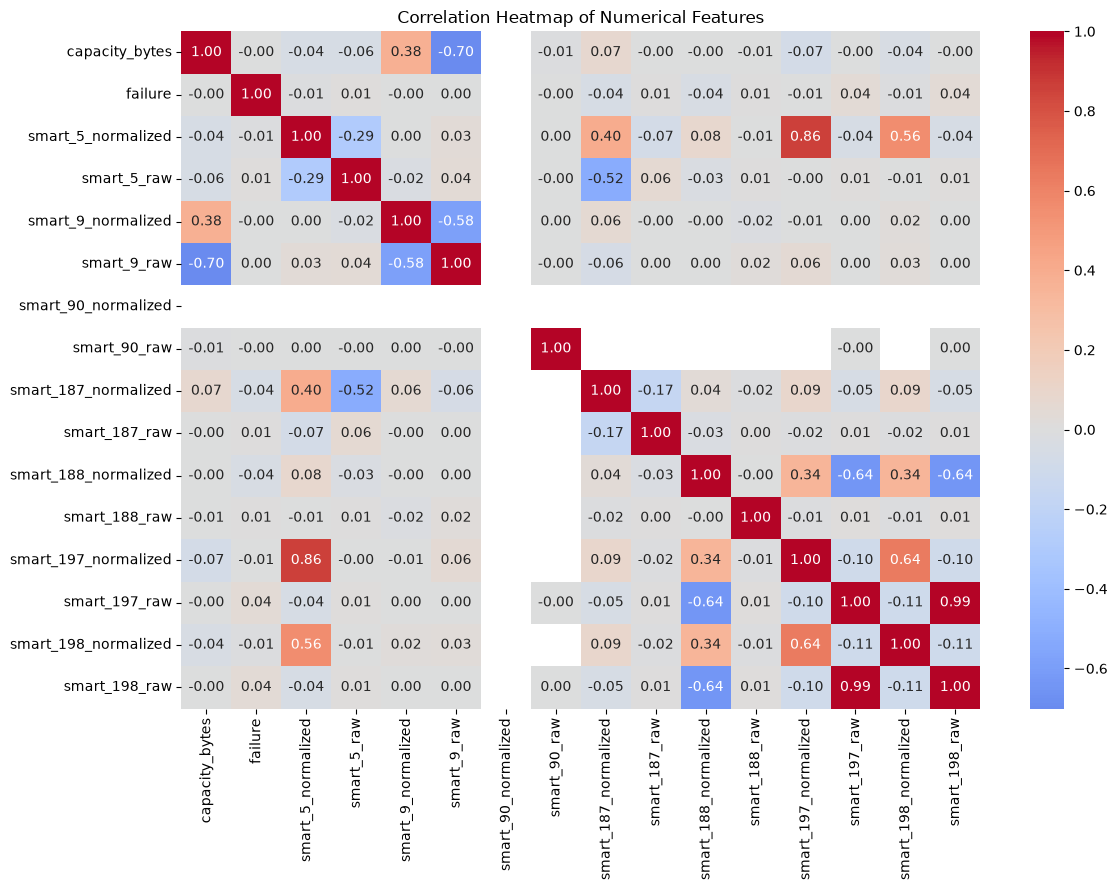


Strongest Correlation:


,Value
Feature_1,smart_197_raw
Feature_2,smart_198_raw
Correlation,0.993962
Absolute_Correlation,0.993962



Interpretation:
The strongest relationship is between smart_197_raw and smart_198_raw, with a correlation of 0.99.

Graph saved: output/visualizations\step_66_correlation_heatmap.png


In [11]:
# ============================================================
# STEP 66 — CORRELATION HEATMAP
# ============================================================

print("\n" + "=" * 70)
print("STEP 66 — CORRELATION HEATMAP")
print("=" * 70)

correlation_matrix = (
    df[numeric_columns]
    .corr()
)

display(
    correlation_matrix
)

print(
    correlation_matrix.to_string()
)

correlation_matrix.to_csv(

    os.path.join(
        OUTPUT_FOLDER,
        "step_66_correlation_matrix.csv"
    ),

    index=True
)


plt.figure(
    figsize=(12, 9)
)

sns.heatmap(

    correlation_matrix,

    annot=True,

    fmt=".2f",

    cmap="coolwarm",

    center=0
)

plt.title(
    "Correlation Heatmap of Numerical Features"
)

plt.tight_layout()

graph_path = os.path.join(
    OUTPUT_FOLDER,
    "step_66_correlation_heatmap.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


corr_pairs = []

for i in range(
    len(correlation_matrix.columns)
):

    for j in range(
        i + 1,
        len(correlation_matrix.columns)
    ):

        corr_value = (
            correlation_matrix.iloc[
                i,
                j
            ]
        )

        corr_pairs.append({

            "Feature_1":
                correlation_matrix.columns[i],

            "Feature_2":
                correlation_matrix.columns[j],

            "Correlation":
                corr_value,

            "Absolute_Correlation":
                abs(corr_value)
        })


corr_pairs_df = pd.DataFrame(
    corr_pairs
)


if len(corr_pairs_df) > 0:

    strongest = corr_pairs_df.loc[
        corr_pairs_df[
            "Absolute_Correlation"
        ].idxmax()
    ]

    interpretation = (

        f"The strongest relationship is between "
        f"{strongest['Feature_1']} and "
        f"{strongest['Feature_2']}, with a "
        f"correlation of "
        f"{strongest['Correlation']:.2f}."
    )

    print(
        "\nStrongest Correlation:"
    )

    display(
        strongest.to_frame(
            "Value"
        )
    )

    print(
        "\nInterpretation:"
    )

    print(
        interpretation
    )

    corr_pairs_df.to_csv(

        os.path.join(
            OUTPUT_FOLDER,
            "step_66_correlation_pairs.csv"
        ),

        index=False
    )

else:

    interpretation = (
        "The heatmap displays relationships "
        "among numerical features."
    )


print(
    "\nGraph saved:",
    graph_path
)


STEP 67 — FAILURE STATUS COMPARISON

STEP 67 — FAILURE STATUS MEANS


,failure,Mean
0,0,1.565091e+13
1,1,1.475768e+13



Saved CSV:
output/visualizations\step_67_failure_status_means.csv


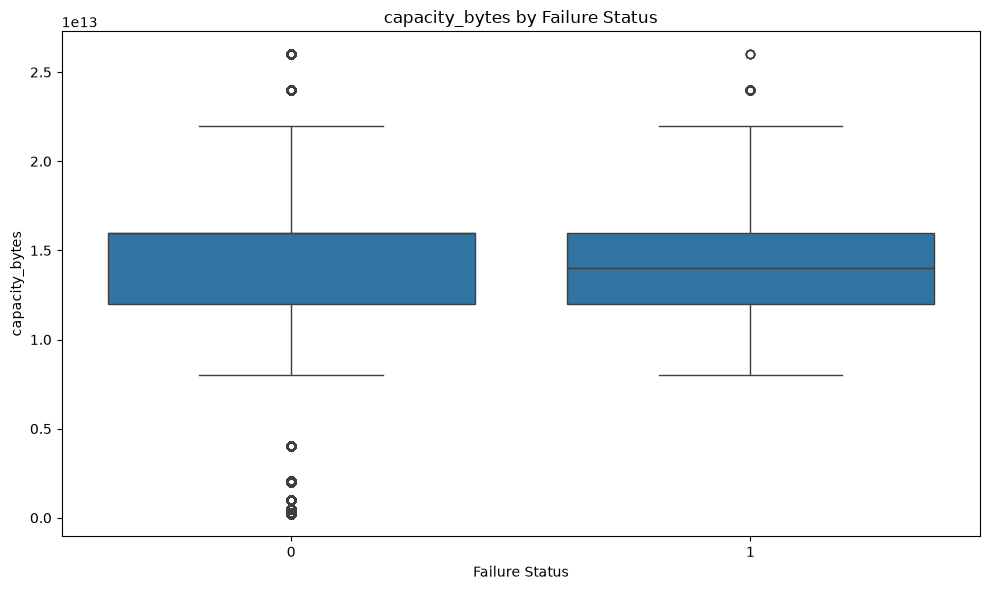


Interpretation:
The comparison shows how capacity_bytes varies between failure-status groups. The group '0' has the highest average value.

Graph saved: output/visualizations\step_67_failure_status_comparison.png


In [12]:
# ============================================================
# STEP 67 — FAILURE STATUS COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("STEP 67 — FAILURE STATUS COMPARISON")
print("=" * 70)

if target_column:

    feature = (
        selected_features[0]
    )

    grouped_means = (

        df

        .groupby(
            target_column
        )[feature]

        .mean()

        .to_frame(
            "Mean"
        )
    )


    show_and_save(

        grouped_means
        .reset_index(),

        "step_67_failure_status_means.csv",

        "STEP 67 — FAILURE STATUS MEANS"
    )


    plt.figure(
        figsize=(10, 6)
    )

    sns.boxplot(

        data=df,

        x=target_column,

        y=feature
    )

    plt.title(
        f"{feature} by Failure Status"
    )

    plt.xlabel(
        "Failure Status"
    )

    plt.ylabel(
        feature
    )

    plt.tight_layout()

    graph_path = os.path.join(

        OUTPUT_FOLDER,

        "step_67_failure_status_comparison.png"
    )

    plt.savefig(

        graph_path,

        dpi=300,

        bbox_inches="tight"
    )

    plt.show()

    plt.close()


    highest_group = (
        grouped_means["Mean"]
        .idxmax()
    )


    interpretation = (

        f"The comparison shows how "
        f"{feature} varies between "
        f"failure-status groups. "
        f"The group '{highest_group}' "
        f"has the highest average value."
    )


    print(
        "\nInterpretation:"
    )

    print(
        interpretation
    )

    print(
        "\nGraph saved:",
        graph_path
    )


else:

    print(
        "Failure target was not detected."
    )

In [13]:
# ============================================================
# STEP 68 — ALL GRAPH INTERPRETATIONS
# ============================================================

print("\n" + "=" * 70)
print("STEP 68 — ALL GRAPH INTERPRETATIONS")
print("=" * 70)

all_interpretations = []


if target_column:

    all_interpretations.append({

        "Step":
            60,

        "Graph":
            "Bar Chart",

        "Interpretation":
            f"The bar chart shows the distribution "
            f"of failure status. "
            f"'{target_counts.idxmax()}' has the "
            f"highest number of records."
    })


all_interpretations.append({

    "Step":
        61,

    "Graph":
        "Line Chart",

    "Interpretation":
        f"The line chart shows the variation "
        f"of {selected_features[0]} over "
        f"time or observations."
})


all_interpretations.append({

    "Step":
        62,

    "Graph":
        "Histogram",

    "Interpretation":
        f"The histogram shows the distribution "
        f"of {selected_features[0]}."
})


if len(selected_features) >= 2:

    all_interpretations.append({

        "Step":
            63,

        "Graph":
            "Scatter Plot",

        "Interpretation":
            f"The scatter plot shows the "
            f"relationship between "
            f"{selected_features[0]} and "
            f"{selected_features[1]}."
    })


all_interpretations.append({

    "Step":
        64,

    "Graph":
        "Box Plot",

    "Interpretation":
        f"The box plot shows the spread, "
        f"median, quartiles and possible "
        f"outliers of {selected_features[0]}."
})


if target_column:

    if len(
        df[target_column].unique()
    ) <= 6:

        all_interpretations.append({

            "Step":
                65,

            "Graph":
                "Pie Chart",

            "Interpretation":
                "The pie chart shows the "
                "proportion of each failure "
                "category."
        })


all_interpretations.append({

    "Step":
        66,

    "Graph":
        "Correlation Heatmap",

    "Interpretation":
        "The heatmap shows the correlation "
        "relationships among numerical features."
})


if target_column:

    all_interpretations.append({

        "Step":
            67,

        "Graph":
            "Failure Status Comparison",

        "Interpretation":
            f"The comparison shows how "
            f"{selected_features[0]} differs "
            f"between failure-status groups."
    })


interpretations_df = pd.DataFrame(
    all_interpretations
)

show_and_save(

    interpretations_df,

    "step_68_all_graph_interpretations.csv",

    "STEP 68 — ALL GRAPH INTERPRETATIONS"
)


STEP 68 — ALL GRAPH INTERPRETATIONS

STEP 68 — ALL GRAPH INTERPRETATIONS


,Step,Graph,Interpretation
0,60,Bar Chart,The bar chart shows the distribution of failur...
1,61,Line Chart,The line chart shows the variation of capacity...
2,62,Histogram,The histogram shows the distribution of capaci...
3,63,Scatter Plot,The scatter plot shows the relationship betwee...
4,64,Box Plot,"The box plot shows the spread, median, quartil..."
5,65,Pie Chart,The pie chart shows the proportion of each fai...
6,66,Correlation Heatmap,The heatmap shows the correlation relationship...
7,67,Failure Status Comparison,The comparison shows how capacity_bytes differ...



Saved CSV:
output/visualizations\step_68_all_graph_interpretations.csv


,Step,Graph,Interpretation
0,60,Bar Chart,The bar chart shows the distribution of failur...
1,61,Line Chart,The line chart shows the variation of capacity...
2,62,Histogram,The histogram shows the distribution of capaci...
3,63,Scatter Plot,The scatter plot shows the relationship betwee...
4,64,Box Plot,"The box plot shows the spread, median, quartil..."
5,65,Pie Chart,The pie chart shows the proportion of each fai...
6,66,Correlation Heatmap,The heatmap shows the correlation relationship...
7,67,Failure Status Comparison,The comparison shows how capacity_bytes differ...


In [14]:
# ============================================================
# STEP 69 — VISUALIZATION SUMMARY
# ============================================================

visualization_summary = pd.DataFrame({

    "Step": [
        60,
        61,
        62,
        63,
        64,
        65,
        66,
        67
    ],

    "Visualization": [

        "Bar Chart",

        "Line Chart",

        "Histogram",

        "Scatter Plot",

        "Box Plot",

        "Pie Chart",

        "Correlation Heatmap",

        "Failure Status Comparison"
    ],

    "Purpose": [

        "Compare categories",

        "Identify trends",

        "Understand distributions",

        "Identify relationships",

        "Identify spread and outliers",

        "Show proportions",

        "Analyze correlations",

        "Compare features by failure status"
    ]
})


show_and_save(

    visualization_summary,

    "step_69_visualization_summary.csv",

    "STEP 69 — VISUALIZATION SUMMARY"
)


STEP 69 — VISUALIZATION SUMMARY


,Step,Visualization,Purpose
0,60,Bar Chart,Compare categories
1,61,Line Chart,Identify trends
2,62,Histogram,Understand distributions
3,63,Scatter Plot,Identify relationships
4,64,Box Plot,Identify spread and outliers
5,65,Pie Chart,Show proportions
6,66,Correlation Heatmap,Analyze correlations
7,67,Failure Status Comparison,Compare features by failure status



Saved CSV:
output/visualizations\step_69_visualization_summary.csv


,Step,Visualization,Purpose
0,60,Bar Chart,Compare categories
1,61,Line Chart,Identify trends
2,62,Histogram,Understand distributions
3,63,Scatter Plot,Identify relationships
4,64,Box Plot,Identify spread and outliers
5,65,Pie Chart,Show proportions
6,66,Correlation Heatmap,Analyze correlations
7,67,Failure Status Comparison,Compare features by failure status


In [15]:
# ============================================================
# STEP 70 — FINAL VISUALIZATION SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 70 — FINAL VISUALIZATION SUMMARY")
print("=" * 70)

png_files = [

    file

    for file in os.listdir(
        OUTPUT_FOLDER
    )

    if file.endswith(
        ".png"
    )
]


csv_files = [

    file

    for file in os.listdir(
        OUTPUT_FOLDER
    )

    if file.endswith(
        ".csv"
    )
]


final_summary = pd.DataFrame({

    "Output_Type": [

        "PNG Graphs",

        "CSV Results"
    ],

    "Number_of_Files": [

        len(png_files),

        len(csv_files)
    ]
})


show_and_save(

    final_summary,

    "step_70_final_visualization_summary.csv",

    "STEP 70 — FINAL VISUALIZATION SUMMARY"
)


print(
    "\nPNG Files:"
)

for file in sorted(
    png_files
):

    print(
        " -",
        file
    )


print(
    "\nCSV Files:"
)

for file in sorted(
    csv_files
):

    print(
        " -",
        file
    )


print(
    "\nOutput Folder:"
)

print(
    OUTPUT_FOLDER
)


print("\n" + "=" * 70)
print(
    "MEMBER 4 — STEPS 57–70 COMPLETED SUCCESSFULLY"
)
print("=" * 70)


STEP 70 — FINAL VISUALIZATION SUMMARY

STEP 70 — FINAL VISUALIZATION SUMMARY


,Output_Type,Number_of_Files
0,PNG Graphs,8
1,CSV Results,14



Saved CSV:
output/visualizations\step_70_final_visualization_summary.csv

PNG Files:
 - step_60_bar_chart.png
 - step_61_line_chart.png
 - step_62_histogram.png
 - step_63_scatter_plot.png
 - step_64_box_plot.png
 - step_65_pie_chart.png
 - step_66_correlation_heatmap.png
 - step_67_failure_status_comparison.png

CSV Files:
 - step_59_selected_features.csv
 - step_60_bar_chart_data.csv
 - step_60_bar_chart_interpretation.csv
 - step_61_line_chart_result.csv
 - step_62_histogram_result.csv
 - step_63_scatter_result.csv
 - step_64_box_plot_result.csv
 - step_65_pie_chart_data.csv
 - step_65_pie_chart_interpretation.csv
 - step_66_correlation_matrix.csv
 - step_66_correlation_pairs.csv
 - step_67_failure_status_means.csv
 - step_68_all_graph_interpretations.csv
 - step_69_visualization_summary.csv

Output Folder:
output/visualizations

MEMBER 4 — STEPS 57–70 COMPLETED SUCCESSFULLY
